<a href="https://colab.research.google.com/github/sheikhmdsamiul/Question-Pair-Similarity-Classification/blob/main/notebooks/siamese_BiLSTM_engineered_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving df_processed_new (1).csv to df_processed_new (1).csv


Loaded the saved updated dataset after processing and feature engineering

In [ ]:
df = pd.read_csv('/content/df_processed_new (1).csv')

In [ ]:
df.head(5)

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_word_count,q2_word_count,...,ctc_min,ctc_max,last_word_eq,first_word_eq,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio,q1_processed,q2_processed
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,66,57,14,12,...,0.833326,0.714281,0.0,1.0,93.0,98.0,93.0,100.0,step step guide invest share market india,step step guide invest share market
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,51,88,8,13,...,0.499994,0.307690,0.0,1.0,66.0,73.0,63.0,86.0,story kohinoor kohinoor diamond,would happen indian government stole kohinoor ...
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,73,59,14,10,...,0.299997,0.214284,0.0,1.0,54.0,53.0,66.0,66.0,increase speed internet connection using vpn,internet speed increased hacking dns
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,50,65,11,9,...,0.000000,0.000000,0.0,0.0,35.0,30.0,36.0,36.0,mentally lonely solve,find remainder mathmath divided
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,76,39,13,7,...,0.285710,0.153845,0.0,1.0,46.0,54.0,47.0,67.0,one dissolve water quikly sugar salt methane c...,fish would survive salt water


In [ ]:
y = df['is_duplicate']

In [ ]:
df_new = df.drop(columns=['id','qid1','qid2', 'question1', 'question2','is_duplicate' ])

In [ ]:
from sklearn.model_selection import train_test_split

# Perform train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    df_new, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of train_df: {X_train.shape}")
print(f"Shape of test_df: {X_test.shape}")

Shape of train_df: (323478, 22)
Shape of test_df: (80870, 22)


In [ ]:
numeric_features_train = X_train.select_dtypes(include=['number']).columns.tolist()
numeric_features_test = X_test.select_dtypes(include=['number']).columns.tolist()

In [ ]:
X_train[numeric_features_train]

,q1_length,q2_length,q1_word_count,q2_word_count,q1_freq,q2_freq,words_Common,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
175485,46,66,9,10,1,1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,40.0,44.0,40.0,40.0
128713,34,58,7,13,1,1,3.0,0.150000,0.199996,0.142855,0.000000,0.000000,0.142855,0.076922,0.0,0.0,47.0,50.0,58.0,60.0
289454,35,48,6,8,1,1,1.0,0.071429,0.249994,0.199996,0.000000,0.000000,0.166664,0.124998,0.0,1.0,47.0,46.0,44.0,47.0
123352,34,35,7,7,1,1,6.0,0.428571,0.799984,0.799984,0.999950,0.999950,0.857131,0.857131,1.0,1.0,99.0,97.0,99.0,99.0
216904,32,46,6,9,1,1,2.0,0.133333,0.499988,0.333328,0.000000,0.000000,0.333328,0.222220,0.0,0.0,50.0,58.0,45.0,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181283,82,85,14,14,1,1,12.0,0.461538,0.888879,0.888879,0.999975,0.999975,0.857137,0.857137,1.0,1.0,90.0,88.0,87.0,94.0
335817,41,42,8,7,1,1,4.0,0.266667,0.799984,0.799984,0.000000,0.000000,0.571420,0.499994,1.0,1.0,64.0,63.0,77.0,81.0
29006,35,44,5,7,1,1,3.0,0.250000,0.666644,0.499988,0.499975,0.333322,0.599988,0.428565,1.0,0.0,81.0,74.0,78.0,92.0
372781,51,60,8,8,1,1,6.0,0.375000,0.499988,0.499988,0.999975,0.999975,0.749991,0.749991,0.0,1.0,84.0,78.0,77.0,87.0


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale numeric features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numeric_features_train])
X_test_scaled = scaler.transform(X_test[numeric_features_test])

StandardScaler to normalize the engineered numeric features, transforming them to have zero mean and unit variance.

In [ ]:
X_train_scaled

array([[-0.45179558,  0.17305917, -0.35758056, ..., -1.25255592,
        -1.42408424, -1.82610734],
       [-0.85253117, -0.06266486, -0.72594872, ..., -0.89481751,
        -0.35847786, -0.72746151],
       [-0.81913654, -0.3573199 , -0.9101328 , ..., -1.13330978,
        -1.18728282, -1.4415813 ],
       ...,
       [-0.81913654, -0.47518192, -1.09431688, ...,  0.53613613,
         0.82552923,  1.0303718 ],
       [-0.28482242, -0.00373386, -0.54176464, ...,  0.7746284 ,
         0.76632888,  0.75571035],
       [ 0.41646486,  0.34985219,  0.37915576, ...,  0.83425147,
         1.12153101,  0.59091348]])

In [ ]:
X_train[numeric_features_train] = X_train_scaled
X_test[numeric_features_test] = X_test_scaled

In [ ]:
X_train[numeric_features_train]

,q1_length,q2_length,q1_word_count,q2_word_count,q1_freq,q2_freq,words_Common,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
175485,-0.451796,0.173059,-0.357581,-0.187503,-0.091704,-0.077661,-1.455960,-1.739975,-1.621107,-1.454611,-1.343353,-1.159431,-1.765542,-1.506866,-0.633149,-0.986855,-1.194220,-1.252556,-1.424084,-1.826107
128713,-0.852531,-0.062665,-0.725949,0.287063,-0.091704,-0.077661,-0.487306,-0.571144,-0.932128,-0.917832,-1.343353,-1.159431,-1.234765,-1.198317,-0.633149,-0.986855,-0.813397,-0.894818,-0.358478,-0.727462
289454,-0.819137,-0.357320,-0.910133,-0.503880,-0.091704,-0.077661,-1.133075,-1.183389,-0.759887,-0.703125,-1.343353,-1.159431,-1.146304,-1.005477,-0.633149,1.013320,-0.813397,-1.133310,-1.187283,-1.441581
123352,-0.852531,-0.740371,-0.725949,-0.662069,-0.091704,-0.077661,0.481349,1.599541,1.134811,1.551334,1.262110,1.987019,1.419120,1.931224,1.579408,1.013320,2.015572,1.907467,2.068737,1.414898
216904,-0.919320,-0.416251,-0.910133,-0.345691,-0.091704,-0.077661,-0.810190,-0.701014,0.101333,-0.202130,-1.343353,-1.159431,-0.527066,-0.615507,-0.633149,-0.986855,-0.650187,-0.417833,-1.128082,-1.166920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181283,0.750411,0.732904,0.563340,0.445252,-0.091704,-0.077661,2.418657,1.856427,1.441051,1.885357,1.262175,1.987097,1.419142,1.931248,1.579408,1.013320,1.525943,1.370859,1.358332,1.140236
335817,-0.618769,-0.534113,-0.541765,-0.662069,-0.091704,-0.077661,-0.164421,0.337946,1.134811,1.551334,-1.343353,-1.159431,0.357566,0.498690,1.579408,1.013320,0.111458,-0.119718,0.766329,0.426117
29006,-0.819137,-0.475182,-1.094317,-0.662069,-0.091704,-0.077661,-0.487306,0.208076,0.675461,0.424095,-0.040621,-0.110597,0.463708,0.212179,1.579408,-0.986855,1.036313,0.536136,0.825529,1.030372
372781,-0.284822,-0.003734,-0.541765,-0.503880,-0.091704,-0.077661,0.481349,1.182101,0.101333,0.424095,1.262175,1.987097,1.021042,1.501468,-0.633149,1.013320,1.199523,0.774628,0.766329,0.755710


Initialize and fit the Keras Tokenizer exclusively on the question1 and question2 columns of the train_df. This ensures the tokenizer learns its vocabulary only from the training set, preventing data leakage from the test set.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Create a combined Series of question1 and question2 from train_df
train_questions = pd.Series(X_train['q1_processed'].tolist() + X_train['q2_processed'].tolist()).astype(str)

# Instantiate a Tokenizer object with num_words=50000
tokenizer = Tokenizer(num_words=50000)

# Fit the tokenizer on the combined Series of training questions
tokenizer.fit_on_texts(train_questions)

Use the tokenizer (fitted on training data) to convert question1 and question2 from the train_df into sequences of integers. Pad these sequences to MAX_SEQUENCE_LENGTH to create q1_data_train and q2_data_train.

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Convert 'question1' from train_df into sequences of integers
q1_train_seq = tokenizer.texts_to_sequences(X_train['q1_processed'].astype(str))

# Convert 'question2' from train_df into sequences of integers
q2_train_seq = tokenizer.texts_to_sequences(X_train['q2_processed'].astype(str))

Calculate the length percentile of each sequence to determine MAX_SEQUENCE_LENGTH

In [ ]:
# Calculate the length of each sequence
sequences = q1_train_seq + q2_train_seq
sequence_lengths = [len(seq) for seq in sequences]

print(f"Total number of questions: {len(sequence_lengths)}")
print(f"Maximum sequence length: {np.max(sequence_lengths)}")
print(f"Average sequence length: {np.mean(sequence_lengths):.2f}")
print(f"90th percentile sequence length: {np.percentile(sequence_lengths, 90):.2f}")
print(f"95th percentile sequence length: {np.percentile(sequence_lengths, 95):.2f}")
print(f"99th percentile sequence length: {np.percentile(sequence_lengths, 99):.2f}")

Total number of questions: 646956
Maximum sequence length: 97
Average sequence length: 5.24
90th percentile sequence length: 9.00
95th percentile sequence length: 11.00
99th percentile sequence length: 15.00


In [ ]:
MAX_SEQUENCE_LENGTH = 20

This parameter is determined based on the percentile distribution of sequence lengths within the training data.

In [ ]:
# Pad the sequences for 'question1'
q1_data_train = pad_sequences(q1_train_seq, maxlen=MAX_SEQUENCE_LENGTH)

# Pad the sequences for 'question2'
q2_data_train = pad_sequences(q2_train_seq, maxlen=MAX_SEQUENCE_LENGTH)

Apply the same tokenizer (fitted on training data) to convert question1 and question2 from the test_df into sequences. Pad these test sequences to MAX_SEQUENCE_LENGTH to create q1_data_test and q2_data_test.

In [ ]:
# Convert 'question1' from test_df into sequences of integers
q1_test_seq = tokenizer.texts_to_sequences(X_test['q1_processed'].astype(str))

# Convert 'question2' from test_df into sequences of integers
q2_test_seq = tokenizer.texts_to_sequences(X_test['q2_processed'].astype(str))

# Pad the sequences for 'question1'
q1_data_test = pad_sequences(q1_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

# Pad the sequences for 'question2'
q2_data_test = pad_sequences(q2_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

Downloading the GloVe embeddings directly from Stanford's website

In [ ]:
# Download the GloVe embeddings using wget
!wget http://nlp.stanford.edu/data/glove.6B.zip [1. 2]

--2025-11-21 09:19:56--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-11-21 09:19:57--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-11-21 09:19:57--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
# Create the embeddings dictionary and matrix
glove_file_path = 'glove.6B.100d.txt'

Loading GloVe Embeddings and Create Embedding Matrix

In [ ]:
!unzip -o -q glove.6B.zip

MAX_NB_WORDS = 50000
EMBEDDING_DIM = 100

embeddings_index = {}
with open(glove_file_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
print(f'Found {len(embeddings_index)} word vectors.')

embedding_matrix = np.zeros((MAX_NB_WORDS, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < MAX_NB_WORDS:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

Found 400000 word vectors.


Creates a matrix of zeros with shape (50000, 100)

For each word in tokenizer's vocabulary:

If the word exists in GloVe embeddings then copies its vector &

If not found: remains as zeros

In [ ]:
print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (50000, 100)


# **Build Simense LSTM Model**

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, Input, LSTM, Dense, Bidirectional, Lambda, Concatenate, LayerNormalization
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import tensorflow as tf

In [ ]:
# Define the embedding layer with the pre-trained matrix
embedding_layer = Embedding(
    input_dim=MAX_NB_WORDS,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_SEQUENCE_LENGTH,
    trainable=False  # Freeze the weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


This layer performs LOOKUP from word indices to dense vectors
Uses the pre-built embedding_matrix as its lookup table

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, Input, LSTM, Dense, Bidirectional, Lambda, Concatenate, LayerNormalization
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import tensorflow as tf

# Shared LSTM encoder (Siamese architecture)
lstm_layer = layers.Bidirectional(
        layers.LSTM(units = 128, return_sequences=False, dropout=0.5),
        name='shared_lstm'
    )

# Input layers
question1_input = layers.Input(shape=(MAX_SEQUENCE_LENGTH,), name='question1')
question2_input = layers.Input(shape=(MAX_SEQUENCE_LENGTH,), name='question2')


# Process both questions through shared layers
q1_embedded = embedding_layer(question1_input)
q2_embedded = embedding_layer(question2_input)

q1_encoded = lstm_layer(q1_embedded)
q2_encoded = lstm_layer(q2_embedded)


# Create interaction features between encodings
# These help the model understand relationships between the two questions
subtracted = layers.Subtract()([q1_encoded, q2_encoded])
multiplied = layers.Multiply()([q1_encoded, q2_encoded])


# Concatenate all representations
concatenated = layers.Concatenate()([
    q1_encoded,
    q2_encoded,
    subtracted,
    multiplied
])


engineered_input = layers.Input(shape=(len(numeric_features_train),), name='engineered_features')

concatenated = layers.Concatenate()([concatenated, engineered_input])

inputs = [question1_input, question2_input, engineered_input]

dense_units=128
dropout_rate=0.5

# Classification head
x = LayerNormalization()(concatenated)
x = layers.Dense(dense_units, activation='relu')(x)
x = layers.Dropout(dropout_rate)(x)
x = LayerNormalization()(x)
x = layers.Dense(dense_units // 2, activation='relu')(x)
x = layers.Dropout(dropout_rate)(x)
output = layers.Dense(1, activation='sigmoid', name='output')(x)


# Build model
model = Model(inputs=inputs, outputs=output, name='siamese_lstm')

- **Architecture :** Siamese BiLSTM + Engineered Features

- This Siamese LSTM architecture was specifically chosen for this task because it effectively captures semantic relationships between question pairs through shared bidirectional LSTM encoders that process both questions with identical weights, ensuring consistent feature extraction.
- The interaction layers (subtract and multiply) explicitly model similarity patterns, while concatenation with engineered features combines deep semantic understanding with statistical signals.
- Parameters like 128 LSTM units and 0.5 dropout rate were selected to balance model capacity for the dataset's vocabulary size and class distribution, with the progressive dense layers (128→64 units) and layer normalization ensuring stable training and effective feature compression for the final binary classification output.

In [ ]:
model.summary()

Model: "siamese_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ question1           │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question2           │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 20, 100)   │  5,000,000 │ question1[0][0],  │
│ (Embedding)         │                   │            │ question2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm         │ (None, 256)       │    234,496 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 256)       │          0 │ shared_lstm[0][0… │
│                     │                   │            │ shared_lstm[1][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 256)       │          0 │ shared_lstm[0][0… │
│                     │                   │            │ shared_lstm[1][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1024)      │          0 │ shared_lstm[0][0… │
│ (Concatenate)       │                   │            │ shared_lstm[1][0… │
│                     │                   │            │ subtract[0][0],   │
│                     │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ engineered_features │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1044)      │          0 │ concatenate[0][0… │
│ (Concatenate)       │                   │            │ engineered_featu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1044)      │      2,088 │ concatenate_1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    133,760 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ dropout[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,378,921 (20.52 MB)

 Trainable params: 378,921 (1.45 MB)

 Non-trainable params: 5,000,000 (19.07 MB)

In [ ]:
# Compile with binary crossentropy
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

Configuring the model for training

- Optimizer: Adam with learning rate 0.001 for efficient gradient-based optimization

- Loss Function: Binary crossentropy - standard for binary classification tasks

Evaluation Metrics:

- Accuracy: Overall correctness

- Precision: Quality of positive predictions (avoid false duplicates)

- Recall: Ability to find all actual duplicates

- AUC: Overall ranking capability between classes

In [ ]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

Adding callbacks for training control mechanisms:

- EarlyStopping: Monitors validation loss and stops training if no improvement after 5 epochs, preventing overfitting while restoring the best weights

- ReduceLROnPlateau: Automatically halves the learning rate when validation loss stagnates for 3 epochs, helping fine-tune convergence

- ModelCheckpoint: Continuously saves the best-performing model based on validation loss, ensuring optimal weights are preserved

These callbacks work together to automate optimal training duration, learning rate adjustment, and model preservation.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Scale them down to be less extreme
#scale_factor = 0.8
class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

As from EDA found class imbalance in the dataset (67% non-duplicate vs 33% duplicate questions) by calculating balanced class weights. The compute_class_weight function automatically assigns higher weight to the minority class (duplicates) and lower weight to the majority class (non-duplicates), ensuring the model doesn't become biased toward predicting the more frequent class.

In [ ]:
print("Training model...")
# Add to model fit
history = model.fit(
    [q1_data_train, q2_data_train, X_train[numeric_features_train]],
    y_train,
    validation_data=([q1_data_test, q2_data_test, X_test[numeric_features_test]], y_test),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Training model...
Epoch 1/30
5053/5055 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7096 - auc: 0.8035 - loss: 0.5111 - precision: 0.5706 - recall: 0.8645
Epoch 1: val_loss improved from inf to 0.45074, saving model to best_model.keras
5055/5055 ━━━━━━━━━━━━━━━━━━━━ 97s 17ms/step - accuracy: 0.7096 - auc: 0.8035 - loss: 0.5111 - precision: 0.5706 - recall: 0.8645 - val_accuracy: 0.7784 - val_auc: 0.8803 - val_loss: 0.4507 - val_precision: 0.6452 - val_recall: 0.8882 - learning_rate: 0.0010
Epoch 2/30
5054/5055 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7668 - auc: 0.8695 - loss: 0.4295 - precision: 0.6288 - recall: 0.8884
Epoch 2: val_loss did not improve from 0.45074
5055/5055 ━━━━━━━━━━━━━━━━━━━━ 85s 17ms/step - accuracy: 0.7668 - auc: 0.8695 - loss: 0.4295 - precision: 0.6288 - recall: 0.8884 - val_accuracy: 0.7840 - val_auc: 0.8949 - val_loss: 0.4625 - val_precision: 0.6464 - val_recall: 0.9162 - learning_rate: 0.0010
Epoch 3/30
5055/5055 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step -

training process

- Input Data: Takes both question sequences (q1_data_train, q2_data_train) along with engineered features

- Training Setup: kept 30 epochs maximum with batch size of 64 for efficient learning

- Validation: Continuously evaluates on test set to monitor generalization

- Optimization: Applies callbacks for early stopping, learning rate adjustment, and model checkpointing

- Class Balancing: Utilizes computed class weights to handle dataset imbalance

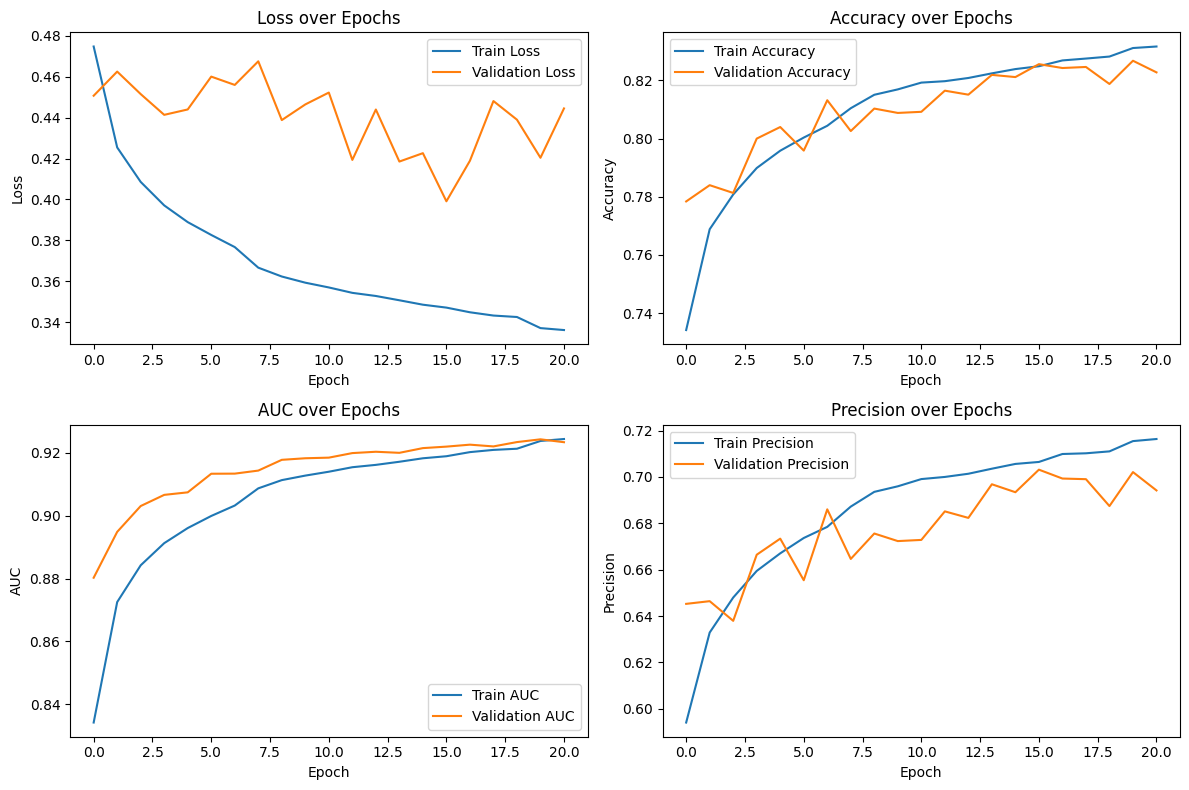

In [ ]:
# Plotting training history
plt.figure(figsize=(12, 8))

# Plot Loss
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot AUC
plt.subplot(2, 2, 3)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

# Plot Precision
plt.subplot(2, 2, 4)
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Validation Precision')
plt.title('Precision over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

plt.tight_layout()
plt.show()

Comprehensive view of the model's learning process across multiple key metrics

Now, let's evaluate the model on the test set.

In [ ]:
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(
    [q1_data_test, q2_data_test, X_test[numeric_features_test]],
    y_test,
    batch_size=64
)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall: {test_recall:.4f}')
print(f'Test AUC: {test_auc:.4f}')

1264/1264 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8252 - auc: 0.9221 - loss: 0.3972 - precision: 0.7035 - recall: 0.9117
Test Loss: 0.3991
Test Accuracy: 0.8256
Test Precision: 0.7031
Test Recall: 0.9134
Test AUC: 0.9220


2528/2528 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step


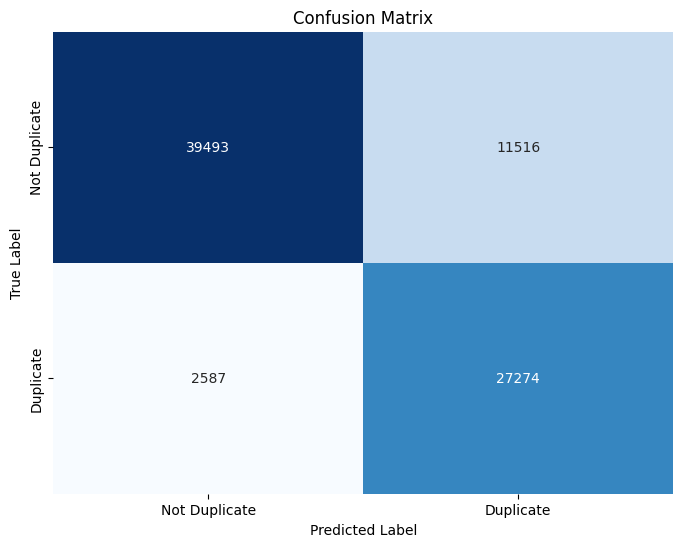

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# Make predictions on the test set
y_pred_proba = model.predict([q1_data_test, q2_data_test, X_test[numeric_features_test]])
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Duplicate', 'Duplicate'], yticklabels=['Not Duplicate', 'Duplicate'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows many Non-Duplicate questions are predicted as Duplicate. This means precision is affected.

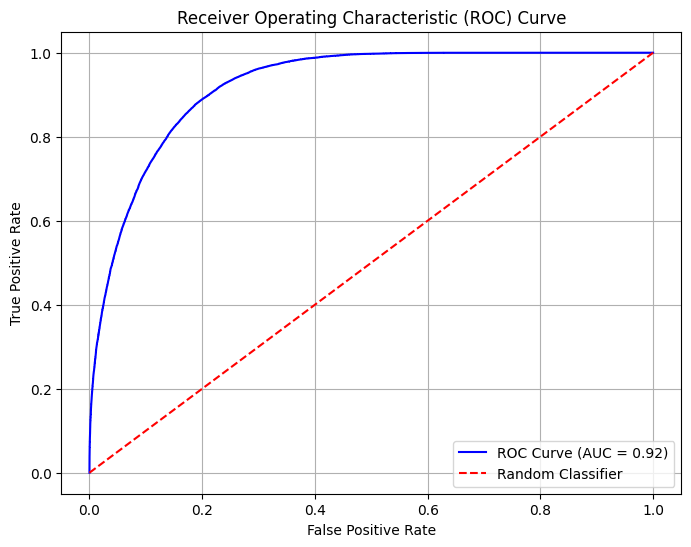

In [ ]:
# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Plot AUC-ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

The ROC curve indicates that the model separates duplicate vs. non-duplicate questions very well. AUC of 0.92 confirms the Siamese BiLSTM + engineered features architecture is capturing semantic similarity effectively.

Moving to Model Tuning and Hyperparameter Optimization

In [ ]:
def build_model(hp):
    # Define the embedding layer with the pre-trained matrix
    embedding_layer = Embedding(
        input_dim=MAX_NB_WORDS,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False  # Freeze the weights
    )

    # Shared LSTM encoder (Siamese architecture)
    lstm_layer = layers.Bidirectional(
            layers.LSTM(units = 128, return_sequences=False, dropout=hp.Choice('lstm_dropout', values=[0.2, 0.3, 0.4, 0.5])),
            name='shared_lstm'
        )

    # Input layers
    question1_input = layers.Input(shape=(MAX_SEQUENCE_LENGTH,), name='question1_input')
    question2_input = layers.Input(shape=(MAX_SEQUENCE_LENGTH,), name='question2_input')
    engineered_input = layers.Input(shape=(len(numeric_features_train),), name='engineered_features_input')

    # Process both questions through shared layers
    q1_embedded = embedding_layer(question1_input)
    q2_embedded = embedding_layer(question2_input)

    q1_encoded = lstm_layer(q1_embedded)
    q2_encoded = lstm_layer(q2_embedded)

    # Create interaction features between encodings
    subtracted = layers.Subtract()([q1_encoded, q2_encoded])
    multiplied = layers.Multiply()([q1_encoded, q2_encoded])

    # Concatenate all representations
    concatenated = layers.Concatenate()([
        q1_encoded,
        q2_encoded,
        subtracted,
        multiplied,
        engineered_input
    ])

    # Classification head
    x = LayerNormalization()(concatenated)
    x = layers.Dense(hp.Choice('dense_units_1', values=[64, 128, 256]), activation='relu')(x)
    x = layers.Dropout(hp.Choice('dropout_rate_1', values=[0.2, 0.3, 0.4, 0.5]))(x)
    x = LayerNormalization()(x)
    x = layers.Dense(hp.Choice('dense_units_2', values=[32, 64, 128]), activation='relu')(x)
    x = layers.Dropout(hp.Choice('dropout_rate_2', values=[0.2, 0.3, 0.4, 0.5]))(x)
    output = layers.Dense(1, activation='sigmoid', name='output')(x)

    # Build model
    model = Model(inputs=[question1_input, question2_input, engineered_input], outputs=output, name='siamese_lstm')

    # Compile with binary crossentropy
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

defined a function build_model that encapsulates the Siamese LSTM model architecture, accepting a hyperparameter object hp to allow for varying LSTM dropout, dense layer units, dropout rates, and learning rates.

Hyperparameter Search Space

- **Learning Rate**: [1e-2, 1e-3, 1e-4]
- **Dropout Rates** (for dense layers): [0.2, 0.3, 0.4, 0.5]
- **Dense Units** (for the first dense layer): [64, 128, 256]

In [ ]:
import sys
!{sys.executable} -m pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 12.8 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

# Initialize the KerasTuner RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_auc',
    max_trials=10,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='siamese_lstm_tuning'
)

# Print a summary of the search space
tuner.search_space_summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Search space summary
Default search space size: 6
lstm_dropout (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4, 0.5], 'ordered': True}
dense_units_1 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout_rate_1 (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4, 0.5], 'ordered': True}
dense_units_2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
dropout_rate_2 (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4, 0.5], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


 initialize the KerasTuner RandomSearch tuner and display a summary of its search space.

In [ ]:
print('Starting hyperparameter search...')
tuner.search(
    [q1_data_train, q2_data_train, X_train[numeric_features_train]],
    y_train,
    epochs=10, # Limiting epochs for tuning speed, actual training might use more
    batch_size=64,
    validation_data=([q1_data_test, q2_data_test, X_test[numeric_features_test]], y_test),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)
print('Hyperparameter search completed.')

Trial 10 Complete [00h 13m 15s]
val_auc: 0.922054648399353

Best val_auc So Far: 0.9274988174438477
Total elapsed time: 02h 39m 02s
Hyperparameter search completed.


execute hyperparameter search using the tuner.search() method, providing the training and validation data, as well as the previously defined callbacks and class weights.

In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters found:")
for key, value in best_hps.values.items():
    print(f"  {key}: {value}")

Best Hyperparameters found:
  lstm_dropout: 0.3
  dense_units_1: 256
  dropout_rate_1: 0.4
  dense_units_2: 64
  dropout_rate_2: 0.3
  learning_rate: 0.001


Retrieved the best model and its optimal hyperparameters found by the KerasTuner RandomSearch

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
print("Best model retrieved from KerasTuner.")

Best model retrieved from KerasTuner.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


best model has been retrieved

In [ ]:
test_loss, test_accuracy, test_precision, test_recall, test_auc = best_model.evaluate(
    [q1_data_test, q2_data_test, X_test[numeric_features_test]],
    y_test,
    batch_size=64
)

print(f'Test Loss (Best Model): {test_loss:.4f}')
print(f'Test Accuracy (Best Model): {test_accuracy:.4f}')
print(f'Test Precision (Best Model): {test_precision:.4f}')
print(f'Test Recall (Best Model): {test_recall:.4f}')
print(f'Test AUC (Best Model): {test_auc:.4f}')

1264/1264 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8318 - auc: 0.9267 - loss: 0.3756 - precision: 0.7124 - recall: 0.9147
Test Loss (Best Model): 0.3744
Test Accuracy (Best Model): 0.8322
Test Precision (Best Model): 0.7120
Test Recall (Best Model): 0.9162
Test AUC (Best Model): 0.9275


evaluate its performance on the test set to obtain the loss, accuracy, precision, recall, and AUC

2528/2528 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step


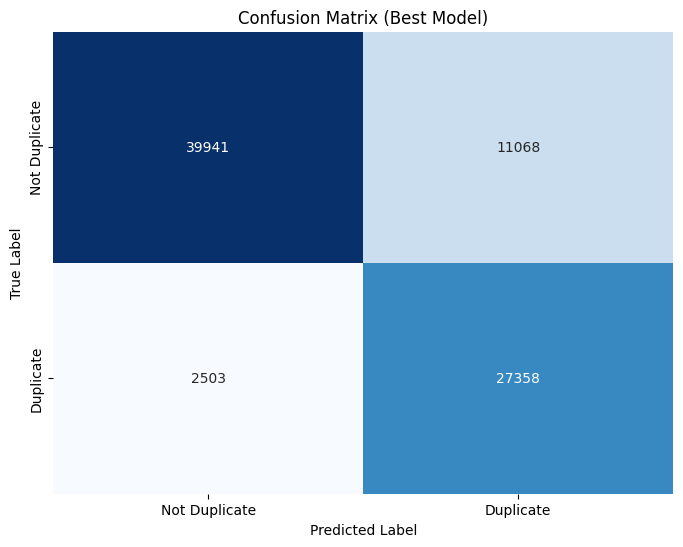

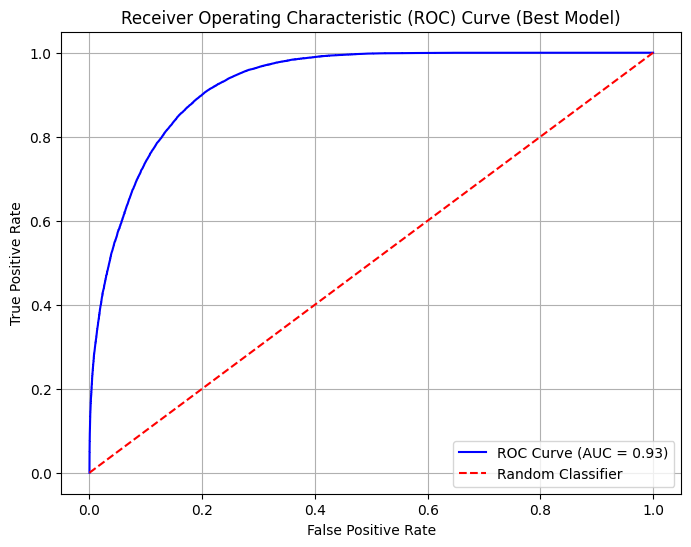

In [ ]:
# Make predictions on the test set using the best model
y_pred_proba_best = best_model.predict([q1_data_test, q2_data_test, X_test[numeric_features_test]])
y_pred_best = (y_pred_proba_best > 0.5).astype(int)

# Calculate Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Duplicate', 'Duplicate'], yticklabels=['Not Duplicate', 'Duplicate'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Best Model)')
plt.show()

# Calculate ROC curve and AUC score
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_pred_proba_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)

# Plot AUC-ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_best, tpr_best, color='blue', label=f'ROC Curve (AUC = {auc_best:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Best Model)')
plt.legend()
plt.grid(True)
plt.show()


plotting a confusion matrix and an AUC-ROC curve for the best model's predictions on the test set.

- After tuning, the model slightly reduced false negatives (2503 from 2587) while keeping true positives high (27,358). This indicates that the optimized architecture better captures semantic similarity across diverse duplicate question patterns.

- The ROC curve shows rapid true positive rate gain with minimal false positive cost

## Comparative Performance Summary: Before vs. After Hyperparameter Optimization


### Model Performance Before Hyperparameter Optimization

From the execution history of cell `3b604712`, the model's performance on the test set *before* hyperparameter optimization was:

- **Test Loss**: 0.3991
- **Test Accuracy**: 0.8256
- **Test Precision**: 0.7031
- **Test Recall**: 0.9134
- **Test AUC**: 0.9220

### Best Model Performance After Hyperparameter Optimization

Based on the evaluation of the best model found by KerasTuner, the following performance metrics were recorded:

*   **Test Loss (Best Model)**: 0.3744
*   **Test Accuracy (Best Model)**: 0.8322
*   **Test Precision (Best Model)**: 0.7120
*   **Test Recall (Best Model)**: 0.9162
*   **Test AUC (Best Model)**: 0.9275

These values indicate the final performance of the Siamese LSTM model after being optimized through the hyperparameter tuning process.

### Analysis of Changes:
- **Test Loss**: Improved significantly from 0.3991 to 0.3744, indicating a better fit to the data.
- **Test Accuracy**: Increased from 0.8256 to 0.8322, showing a slight improvement in overall correct predictions.
- **Test Precision**: Improved from 0.7031 to 0.7120, suggesting a minor reduction in false positives.
- **Test Recall**: Increased slightly from 0.9134 to 0.9162, indicating a marginally better ability to identify positive cases.
- **Test AUC**: Improved from 0.9220 to 0.9275, demonstrating a better distinction between positive and negative classes across various thresholds.

### Overall Impact of Tuning:
Hyperparameter optimization had a positive overall impact on the Siamese LSTM model's performance. All key metrics (Loss, Accuracy, Precision, Recall, and AUC) showed improvement, albeit some more significantly than others. The most notable improvements were in Test Loss and Test AUC, suggesting that tuning helped the model generalize better and become more robust in distinguishing between duplicate and non-duplicate questions. The minor increases in accuracy, precision, and recall indicate a refined model that is slightly more effective at its core task of identifying semantic similarity. This optimization process successfully enhanced the model's predictive power without degrading any specific performance aspect.